## Analyzing the Landslide Data

This will include all the Features that are necessary for the Landslide prediction to work, also make sure to visualize the data with graphs and plots that will shown. 

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing._encoders import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from typing_extensions import Tuple, Optional

In [2]:
# Paths
dir_path = "../../data/final_landslide_rainfall_data_ne.csv"

In [3]:
## loading the data
df = pd.read_csv(dir_path)

df.head()

,id_x,slide_id,source,year,state,district,ls_name,location,nh_sh_affected,lat,...,soil_moisture_0_7cm_avg,soil_moisture_7_28cm_avg,daily_rainfall_mm,cumulative_rainfall_3d_mm,cumulative_rainfall_7d_mm,elev_1,slope_1,aspect_1,tpi_1,rough_1
0,52,NewspaperandMedia_2020_Meghalaya_52,NewspaperandMedia,2020,Meghalaya,Ri-bhoi,Shobhala,"NH 06, Umsning",NH 06,25.746000,...,0.496833,0.488542,17.9,159.7,170.4,771.440979,89.995613,6.095383,-0.703003,8.395081
1,37,NewspaperandMedia_2020_Manipur_37,NewspaperandMedia,2020,Manipur,Senapati,Khongnem-Thana,Khongnem Thana,NH 2 - Imphal-Mao Sector,25.355955,...,0.509833,0.517375,50.8,95.5,132.7,1203.543213,89.998268,277.316010,1.623047,21.178467
2,101,SDMA_2020_Mizoram_103,SDMA,2020,Mizoram,Kolasib,Tumpui_veng1,Tumpui Veng,NaN,24.231943,...,0.404208,0.404250,3.0,36.8,48.7,676.597595,89.996902,126.165649,-2.284363,12.811218
3,93,SDMA_2020_Mizoram_94,SDMA,2020,Mizoram,Aizawl,Phullen3,Phullen,NaN,23.841110,...,0.324667,0.338167,1.4,5.3,23.0,1066.028687,89.999329,225.538391,-2.040527,70.587891
4,64,SDMA_2020_Mizoram_64,SDMA,2020,Mizoram,Aizawl,Zembawk_1,Zemabawk,NaN,23.731928,...,0.396667,0.383667,3.2,34.8,56.3,867.651794,89.999260,296.027344,0.409241,55.350647


In [4]:
## Total Info of the data

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1364 entries, 0 to 1363
Data columns (total 53 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_x                       1364 non-null   int64  
 1   slide_id                   1364 non-null   str    
 2   source                     1364 non-null   str    
 3   year                       1364 non-null   int64  
 4   state                      1364 non-null   str    
 5   district                   1362 non-null   str    
 6   ls_name                    1364 non-null   str    
 7   location                   1105 non-null   str    
 8   nh_sh_affected             588 non-null    str    
 9   lat                        1364 non-null   float64
 10  lon                        1364 non-null   float64
 11  date_of_event              1364 non-null   str    
 12  time_of_event              276 non-null    str    
 13  type_of_event              1362 non-null   str    
 14  cas

In [16]:
## Dropping useless Columns
drop_cols = [
    # Metadata & IDs
    "id_x", "slide_id", "source", "ls_name", "url",
    
    # Target leakage / Consequence
    "casualty", "status", "nh_sh_affected",
    
    # Sparse hourly rainfall & timestamp
    "time_of_event",
    *[f"hour_{i:02d}" for i in range(24)],
    
    # Redundant text/string features
    "rainfall_24hr_mm", "location", "district", "state", "date_of_event", "type_of_event", "year"
]
df_clean = df.drop(columns=drop_cols)

df_clean.head()

,lat,lon,geometry,soil_moisture_0_7cm_avg,soil_moisture_7_28cm_avg,daily_rainfall_mm,cumulative_rainfall_3d_mm,cumulative_rainfall_7d_mm,elev_1,slope_1,aspect_1,tpi_1,rough_1
0,25.746000,91.889000,POINT (91.889 25.746),0.496833,0.488542,17.9,159.7,170.4,771.440979,89.995613,6.095383,-0.703003,8.395081
1,25.355955,94.065280,POINT (94.06528 25.355955),0.509833,0.517375,50.8,95.5,132.7,1203.543213,89.998268,277.316010,1.623047,21.178467
2,24.231943,92.675280,POINT (92.67528 24.231943),0.404208,0.404250,3.0,36.8,48.7,676.597595,89.996902,126.165649,-2.284363,12.811218
3,23.841110,93.051940,POINT (93.05194 23.84111),0.324667,0.338167,1.4,5.3,23.0,1066.028687,89.999329,225.538391,-2.040527,70.587891
4,23.731928,92.760025,POINT (92.760025 23.731928),0.396667,0.383667,3.2,34.8,56.3,867.651794,89.999260,296.027344,0.409241,55.350647


In [6]:
## Visualizing the data with Geopandas

gdf = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["lon"],df_clean["lat"]),
    crs="EPSG:4326"
)

gdf.explore()

In [9]:
import geopandas as gpd
from shapely.ops import unary_union

if gdf.crs is None:
    gdf.set_crs(epsg=4326, inplace=True)

utm_crs = gdf.estimate_utm_crs()
gdf_utm = gdf.to_crs(utm_crs)

buffer_geom = gdf_utm.geometry.buffer(1000)
buffer_gdf = gpd.GeoDataFrame(geometry=buffer_geom, crs=utm_crs).dissolve()

m = buffer_gdf.explore(
    color="red",
    style_kwds={"fillOpacity": 0.3, "weight": 2},
    name="1 km Buffer"
)

gdf.explore(
    m=m,
    color="blue",
    marker_kwds={"radius": 4},
    name="Landslide Points"
)

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer
from shapely.geometry import Point

# ==============================================================================
# 1. LOAD & PREPARE NORTH EAST BOUNDARY
# ==============================================================================
# Load India state boundaries directly from DataMeet open GeoJSON
url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"
india_gdf = gpd.read_file(url)

# Filter for the 8 North East States
ne_states = [
    "Arunachal Pradesh",
    "Assam",
    "Manipur",
    "Meghalaya",
    "Mizoram",
    "Nagaland",
    "Sikkim",
    "Tripura",
]

ne_boundary_gdf = india_gdf[india_gdf["NAME_1"].isin(ne_states)].to_crs(
    epsg=4326
)

# If column name differs in your version, standard alternative:
if len(ne_boundary_gdf) == 0:
    state_col = [c for c in india_gdf.columns if "name" in c.lower() or "st" in c.lower()][0]
    ne_boundary_gdf = india_gdf[india_gdf[state_col].isin(ne_states)].to_crs(epsg=4326)

# ==============================================================================
# 2. FILTER POSITIVE POINTS TO NORTH EAST ONLY
# ==============================================================================
if gdf.crs is None:
    gdf.set_crs(epsg=4326, inplace=True)
else:
    gdf = gdf.to_crs(epsg=4326)

positives_gdf = gpd.clip(gdf, ne_boundary_gdf)

utm_crs = positives_gdf.estimate_utm_crs()
positives_utm = positives_gdf.to_crs(utm_crs)
ne_boundary_utm = ne_boundary_gdf.to_crs(utm_crs)
ne_geom = ne_boundary_utm.geometry.unary_union

# 1 km buffer around positives
buffer_geom = positives_utm.geometry.buffer(1000).unary_union

# ==============================================================================
# 3. SAMPLE NEGATIVES STRICTLY INSIDE NORTH EAST BOUNDARY
# ==============================================================================
lulc_path = "data/LULC.tif"
FLAT_LULC_CLASSES = {1, 5}  # Adjust to your flat LULC pixel values

with rasterio.open(lulc_path) as src:
    raster_crs = src.crs

utm_to_raster = Transformer.from_crs(utm_crs, raster_crs, always_xy=True)

# Constrain coordinate generator to the exact North East boundary bounds
minx, miny, maxx, maxy = ne_geom.bounds

num_negatives_needed = len(positives_utm)
negative_points = []
batch_size = max(1000, num_negatives_needed * 3)

with rasterio.open(lulc_path) as src:
    while len(negative_points) < num_negatives_needed:
        rand_x = np.random.uniform(minx, maxx, size=batch_size)
        rand_y = np.random.uniform(miny, maxy, size=batch_size)
        candidates = [Point(x, y) for x, y in zip(rand_x, rand_y)]

        # Filter 1: Strictly inside NE India
        # Filter 2: Outside the 1 km positive landslide buffer
        valid_candidates = [
            pt
            for pt in candidates
            if ne_geom.contains(pt) and not buffer_geom.contains(pt)
        ]

        if not valid_candidates:
            continue

        # Filter 3: Verify flat ground via LULC raster
        raster_coords = [
            utm_to_raster.transform(pt.x, pt.y) for pt in valid_candidates
        ]
        sampled_values = [val[0] for val in src.sample(raster_coords)]

        for pt, val in zip(valid_candidates, sampled_values):
            if val in FLAT_LULC_CLASSES:
                negative_points.append(pt)
                if len(negative_points) >= num_negatives_needed:
                    break

# ==============================================================================
# 4. EXPORT MASTER DATASET (NORTH EAST ONLY)
# ==============================================================================
negatives_gdf = gpd.GeoDataFrame(
    {"label": [0] * len(negative_points)},
    geometry=negative_points,
    crs=utm_crs,
).to_crs(epsg=4326)
negatives_gdf["latitude"] = negatives_gdf.geometry.y
negatives_gdf["longitude"] = negatives_gdf.geometry.x

positives_gdf["label"] = 1
positives_gdf["latitude"] = positives_gdf.geometry.y
positives_gdf["longitude"] = positives_gdf.geometry.x

master_gdf = pd.concat(
    [
        positives_gdf[["label", "latitude", "longitude", "geometry"]],
        negatives_gdf[["label", "latitude", "longitude", "geometry"]],
    ],
    ignore_index=True,
)

master_gdf = gpd.GeoDataFrame(master_gdf, geometry="geometry", crs="EPSG:4326")
master_gdf.to_file("landslide_ne_master_dataset.geojson", driver="GeoJSON")
master_gdf.to_csv("landslide_ne_master_dataset.csv", index=False)

print(f"Extraction complete (North East India Only):")
print(f" - Positives: {len(positives_gdf)}")
print(f" - Negatives: {len(negatives_gdf)}")
print(f" - Total:     {len(master_gdf)}")

C:\Users\biswa\AppData\Local\Temp\ipykernel_19960\3705011776.py:51: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ne_geom = ne_boundary_utm.geometry.unary_union
C:\Users\biswa\AppData\Local\Temp\ipykernel_19960\3705011776.py:54: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_geom = positives_utm.geometry.buffer(1000).unary_union


Extraction complete (North East India Only):
 - Positives: 1355
 - Negatives: 1355
 - Total:     2710


In [22]:
m = buffer_gdf.explore(
    color="red",
    style_kwds={"fillOpacity": 0.3, "weight": 2},
    name="1 km Buffer"
)

negatives_gdf.explore(
    m=m
)

In [23]:
ne_boundary_gdf = india_gdf[india_gdf["NAME_1"].isin(ne_states)].to_crs(
    epsg=4326
)

ne_boundary_gdf.explore()

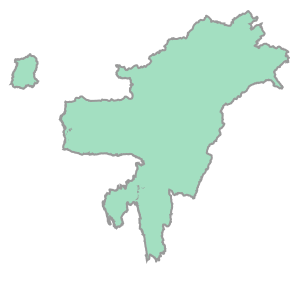

In [24]:
ne_geom

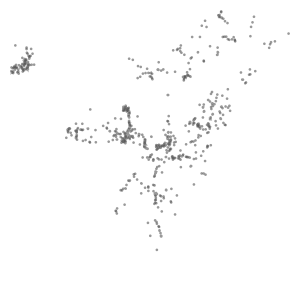

In [25]:
buffer_geom

In [26]:
positives_gdf

,year,lat,lon,date_of_event,type_of_event,geometry,soil_moisture_0_7cm_avg,soil_moisture_7_28cm_avg,daily_rainfall_mm,cumulative_rainfall_3d_mm,cumulative_rainfall_7d_mm,elev_1,slope_1,aspect_1,tpi_1,rough_1,label,latitude,longitude
619,2024,23.167875,91.516870,2024/08/19,2,POINT (91.51687 23.16788),0.509708,0.515708,87.6,193.9,206.7,51.278816,89.992332,159.484192,2.336422,7.545723,1,23.167875,91.516870
310,2021,23.228159,91.494286,2021/08/26,2,POINT (91.49429 23.22816),0.502000,0.487000,7.5,32.4,51.9,38.433857,89.995827,313.922943,-2.145958,12.512573,1,23.228159,91.494286
308,2021,23.246300,91.480730,2021/08/26,2,POINT (91.48073 23.2463),0.502000,0.487000,7.5,32.4,51.9,26.304155,89.994354,108.464508,-2.383989,8.161966,1,23.246300,91.480730
616,2024,23.312970,91.524155,2024/08/22,2,POINT (91.52416 23.31297),0.505500,0.512792,23.5,257.4,372.9,44.353714,89.988197,11.163673,0.822914,4.776203,1,23.312970,91.524155
591,2023,23.837263,91.628720,2023/03/31,2,POINT (91.62872 23.83726),0.369250,0.331250,6.1,25.2,35.3,49.924423,89.982796,326.386414,0.600063,3.558765,1,23.837263,91.628720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1184,2025,28.805548,94.801384,2025/04/02,2,POINT (94.80138 28.80555),0.386458,0.383208,5.1,12.3,27.4,643.681946,89.997910,83.576218,1.325500,17.804199,1,28.805548,94.801384
317,2021,28.849610,94.748650,2021/08/13,3,POINT (94.74865 28.84961),0.428042,0.428292,83.3,470.4,591.7,698.128662,89.998688,67.139923,4.387878,33.982178,1,28.849610,94.748650
1340,2026,28.858644,94.788530,2026/06/10,2,POINT (94.78853 28.85864),0.425625,0.426542,48.4,97.1,119.2,928.157410,89.999054,44.239605,2.555359,48.350769,1,28.858644,94.788530
356,2021,28.936253,94.842540,2021/06/17,2,POINT (94.84254 28.93625),0.419250,0.419167,6.4,63.4,123.1,683.192749,89.999283,38.722691,1.214600,61.672852,1,28.936253,94.842540


In [29]:
type(positives_gdf["date_of_event"][0])

str

In [27]:
negatives_gdf

,label,geometry,latitude,longitude
0,0,POINT (94.09258 26.36486),26.364860,94.092582
1,0,POINT (94.23932 26.96591),26.965906,94.239323
2,0,POINT (92.02305 26.12342),26.123416,92.023051
3,0,POINT (90.50765 26.10791),26.107906,90.507648
4,0,POINT (94.92459 27.05913),27.059130,94.924585
...,...,...,...,...
1350,0,POINT (92.26876 26.21632),26.216324,92.268758
1351,0,POINT (92.78517 24.62561),24.625608,92.785170
1352,0,POINT (92.16528 26.63584),26.635845,92.165278
1353,0,POINT (90.45326 26.00994),26.009941,90.453258


In [30]:
negatives_gdf["date_of_event"] = "2024/3/17"

In [33]:
final_dataset_with_nagatives = pd.concat(
    [
        positives_gdf[["label", "latitude", "longitude", "geometry","date_of_event"]],
        negatives_gdf[["label", "latitude", "longitude", "geometry","date_of_event"]],
    ],
    ignore_index=True
)

len(final_dataset_with_nagatives)

2710

In [34]:
final_dataset_with_nagatives

,label,latitude,longitude,geometry,date_of_event
0,1,23.167875,91.516870,POINT (91.51687 23.16788),2024/08/19
1,1,23.228159,91.494286,POINT (91.49429 23.22816),2021/08/26
2,1,23.246300,91.480730,POINT (91.48073 23.2463),2021/08/26
3,1,23.312970,91.524155,POINT (91.52416 23.31297),2024/08/22
4,1,23.837263,91.628720,POINT (91.62872 23.83726),2023/03/31
...,...,...,...,...,...
2705,0,26.216324,92.268758,POINT (92.26876 26.21632),2024/3/17
2706,0,24.625608,92.785170,POINT (92.78517 24.62561),2024/3/17
2707,0,26.635845,92.165278,POINT (92.16528 26.63584),2024/3/17
2708,0,26.009941,90.453258,POINT (90.45326 26.00994),2024/3/17


In [35]:
import pandas as pd
import time
import requests
from tqdm.auto import tqdm


def fetch_robust(lat, lon, target_date):
    target_dt = pd.to_datetime(target_date).tz_localize("UTC")
    start_dt = target_dt - pd.Timedelta(days=7)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_dt.strftime("%Y-%m-%d"),
        "end_date": target_dt.strftime("%Y-%m-%d"),
        # Open-Meteo REST API requires comma-separated strings
        "hourly": "soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,precipitation",
        "timezone": "UTC",
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        hourly = data["hourly"]
        df = pd.DataFrame(
            {
                "time": pd.to_datetime(hourly["time"], utc=True),
                "soil_0_7": hourly["soil_moisture_0_to_7cm"],
                "soil_7_28": hourly["soil_moisture_7_to_28cm"],
                "precip": hourly["precipitation"],
            }
        )

        target_mask = df["time"].dt.date == target_dt.date()
        past_3d_mask = df["time"] >= (target_dt - pd.Timedelta(days=3))

        return {
            "soil_moisture_0_7cm_avg": df.loc[target_mask, "soil_0_7"].mean(),
            "soil_moisture_7_28cm_avg": df.loc[target_mask, "soil_7_28"].mean(),
            "daily_rainfall_mm": df.loc[target_mask, "precip"].sum(),
            "cumulative_rainfall_3d_mm": df.loc[past_3d_mask, "precip"].sum(),
            "cumulative_rainfall_7d_mm": df["precip"].sum(),
        }
    except Exception as e:
        print(f"Error: {e}")
        time.sleep(5)
        return None

c:\Users\biswa\AI Models\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
results = []
for _, row in tqdm(
    final_dataset_with_nagatives.iterrows(),
    total=len(final_dataset_with_nagatives),
    desc="Fetching Weather Data",
):
    features = fetch_robust(row["latitude"], row["longitude"], row["date_of_event"])

    # Fill with NaNs if the fetch fails
    if features is None:
        features = {
            "soil_moisture_0_7cm_avg": None,
            "soil_moisture_7_28cm_avg": None,
            "daily_rainfall_mm": None,
            "cumulative_rainfall_3d_mm": None,
            "cumulative_rainfall_7d_mm": None,
        }
    results.append(features)
    time.sleep(0.05)  # Avoid hitting API rate limits

# Join back to the original GeoDataFrame
features_df = pd.DataFrame(results, index=final_dataset_with_nagatives.index)
gdf = pd.concat([final_dataset_with_nagatives, features_df], axis=1)

print(gdf.head())

Fetching Weather Data:  35%|███▍      | 938/2710 [16:50<32:00,  1.08s/it]

Error: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


Fetching Weather Data:  48%|████▊     | 1295/2710 [23:25<26:41,  1.13s/it] 

Error: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


Fetching Weather Data:  64%|██████▍   | 1738/2710 [32:12<19:31,  1.21s/it]  

...

Error: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


Fetching Weather Data:  96%|█████████▌| 2605/2710 [51:03<02:05,  1.19s/it]

Error: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Max retries exceeded with url: /v1/archive?latitude=26.38410121911576&longitude=92.02760165535682&start_date=2024-03-10&end_date=2024-03-17&hourly=soil_moisture_0_to_7cm%2Csoil_moisture_7_to_28cm%2Cprecipitation&timezone=UTC (Caused by ConnectTimeoutError(<HTTPSConnection(host='archive-api.open-meteo.com', port=443) at 0x196af385610>, 'Connection to archive-api.open-meteo.com timed out. (connect timeout=10)'))


Fetching Weather Data: 100%|██████████| 2710/2710 [53:33<00:00,  1.19s/it]


   label   latitude  longitude                   geometry date_of_event  \
0      1  23.167875  91.516870  POINT (91.51687 23.16788)    2024/08/19   
1      1  23.228159  91.494286  POINT (91.49429 23.22816)    2021/08/26   
2      1  23.246300  91.480730   POINT (91.48073 23.2463)    2021/08/26   
3      1  23.312970  91.524155  POINT (91.52416 23.31297)    2024/08/22   
4      1  23.837263  91.628720  POINT (91.62872 23.83726)    2023/03/31   

   soil_moisture_0_7cm_avg  soil_moisture_7_28cm_avg  daily_rainfall_mm  \
0                 0.509708                  0.515708               87.6   
1                 0.502000                  0.487000                7.5   
2                 0.502000                  0.487000                7.5   
3                 0.505500                  0.512792               23.5   
4                 0.369250                  0.331250                6.1   

   cumulative_rainfall_3d_mm  cumulative_rainfall_7d_mm  
0                      193.9            

In [26]:
gdf = pd.read_csv("data/final_landslide_with_negatives.csv")

gdffinal = gpd.GeoDataFrame(
    gdf,
    geometry= gpd.points_from_xy(pd.to_numeric(gdf["longitude"]), pd.to_numeric(gdf["latitude"]))
)

gdffinal

,id,label,latitude,longitude,geometry,date_of_event,soil_moisture_0_7cm_avg,soil_moisture_7_28cm_avg,daily_rainfall_mm,cumulative_rainfall_3d_mm,cumulative_rainfall_7d_mm
0,0,1,23.167875,91.516870,POINT (91.51687 23.16788),2024/08/19,0.509708,0.515708,87.6,193.9,206.7
1,1,1,23.228159,91.494286,POINT (91.49429 23.22816),2021/08/26,0.502000,0.487000,7.5,32.4,51.9
2,2,1,23.246300,91.480730,POINT (91.48073 23.2463),2021/08/26,0.502000,0.487000,7.5,32.4,51.9
3,3,1,23.312970,91.524155,POINT (91.52416 23.31297),2024/08/22,0.505500,0.512792,23.5,257.4,372.9
4,4,1,23.837263,91.628720,POINT (91.62872 23.83726),2023/03/31,0.369250,0.331250,6.1,25.2,35.3
...,...,...,...,...,...,...,...,...,...,...,...
2705,2705,0,26.216324,92.268758,POINT (92.26876 26.21632),2024/3/17,0.294250,0.310833,0.0,0.0,0.0
2706,2706,0,24.625608,92.785170,POINT (92.78517 24.62561),2024/3/17,0.309583,0.306667,0.0,7.2,7.3
2707,2707,0,26.635845,92.165278,POINT (92.16528 26.63584),2024/3/17,0.257417,0.286958,0.0,0.0,0.4
2708,2708,0,26.009941,90.453258,POINT (90.45326 26.00994),2024/3/17,0.255958,0.318083,0.0,0.0,0.0


In [16]:
minx, miny, maxx, maxy = gdffinal.total_bounds

minx , miny , maxx , maxy

(np.float64(88.08848),
 np.float64(22.130154),
 np.float64(97.01467),
 np.float64(29.09357353676605))

In [44]:
import numpy as np
from PIL import Image
from pystac_client import Client
import planetary_computer as pc
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

lon = 91.516870
lat = 23.167875
BOX_SIZE = 0.0072  # ~1.5 km box

start_date = "2023-06-01"
end_date = "2023-07-31"
bbox_4326 = [lon - BOX_SIZE, lat - BOX_SIZE, lon + BOX_SIZE, lat + BOX_SIZE]

# 1. Search for clearest scene
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_4326,
    datetime=f"{start_date}/{end_date}",
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
    max_items=1
)

items = list(search.items())
best_scene = pc.sign(items[0])

print(f"Downloading from scene captured on: {best_scene.datetime.strftime('%Y-%m-%d')}")

# 2. Stream, reproject bbox, and crop
visual_url = best_scene.assets["visual"].href

with rasterio.open(visual_url) as src:
    # Convert lat/lon bounds (EPSG:4326) to the raster's native UTM projection
    proj_bbox = transform_bounds("EPSG:4326", src.crs, *bbox_4326)
    
    # Calculate pixel window using projected coordinates
    window = from_bounds(*proj_bbox, transform=src.transform)
    
    # boundless=True prevents out-of-range errors on scene edges
    rgb = src.read([1, 2, 3], window=window, out_shape=(3, 224, 224), boundless=True)
    rgb = np.moveaxis(rgb, 0, -1)  # Reshape to [224, 224, 3]

# 3. Save output image
img = Image.fromarray(rgb.astype(np.uint8))
img.save("test_patch.jpg")
print("Saved test_patch.jpg successfully.")

APIError: <!DOCTYPE html PUBLIC '-//W3C//DTD XHTML 1.0 Transitional//EN' 'http://www.w3.org/TR/xhtml1/DTD/xhtml1-transitional.dtd'>
<html xmlns='http://www.w3.org/1999/xhtml'>

<head>
    <meta content='text/html; charset=utf-8' http-equiv='content-type' />
    <style type='text/css'>
        body {
            font-family: Arial;
            margin-left: 40px;
        }

        img {
            border: 0 none;
        }

        #content {
            margin-left: auto;
            margin-right: auto
        }

        #message h1 {
            font-size: 24px;
            font-weight: normal;
            color: #000000;
            margin: 34px 0px 0px 0px
        }

        #message h2 {
            font-size: 20px;
            font-weight: normal;
            color: #000000;
            margin: 34px 0px 0px 0px
        }

        #message p {
            font-size: 16px;
            color: #000000;
            margin: 8px 0px 0px 0px
        }

        #message hr {
            m

In [34]:
from pystac_client import Client
import pandas as pd

catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

lon = 91.516870
lat = 23.167875
BOX_SIZE = 0.012

# Set your actual test dates here
start_date = "2023-06-01"
end_date = "2023-07-31"

bbox = [lon - BOX_SIZE, lat - BOX_SIZE, lon + BOX_SIZE, lat + BOX_SIZE]

# Search with NO cloud filtering to see if raw satellite passes exist
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=f"{start_date}/{end_date}",
    max_items=10
)

items = list(search.items())
print(f"Total scenes found: {len(items)}")

for item in items:
    print(f"Date: {item.datetime.strftime('%Y-%m-%d')} | Cloud Cover: {item.properties['eo:cloud_cover']:.1f}%")

Total scenes found: 10
Date: 2023-07-30 | Cloud Cover: 45.1%
Date: 2023-07-30 | Cloud Cover: 60.5%
Date: 2023-07-25 | Cloud Cover: 28.9%
Date: 2023-07-25 | Cloud Cover: 43.3%
Date: 2023-07-20 | Cloud Cover: 57.6%
Date: 2023-07-20 | Cloud Cover: 57.6%
Date: 2023-07-15 | Cloud Cover: 63.6%
Date: 2023-07-15 | Cloud Cover: 71.6%
Date: 2023-07-10 | Cloud Cover: 96.5%
Date: 2023-07-10 | Cloud Cover: 97.7%


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from pystac_client import Client
import planetary_computer as pc

# 1. Setup folders
os.makedirs("data/sat_data/landslide", exist_ok=True)
os.makedirs("data/sat_data/non_landslide", exist_ok=True)

df = pd.read_csv("data/final_landslide_with_negatives.csv")
catalog = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

BOX_SIZE = 0.0048  # ~2.5 km box

for idx, row in df.iterrows():
    lat = float(row["latitude"])
    lon = float(row["longitude"])
    label = int(row["label"])
    event_date = pd.to_datetime(row["date_of_event"])

    folder = "landslide" if label == 1 else "non_landslide"
    save_path = f"data/sat_data/{folder}/img_{idx:04d}.jpg"

    if os.path.exists(save_path):
        continue

    # Dry-Season Search Window (North East India cloud-free period)
    year = event_date.year
    month = event_date.month

    if month >= 5:
        # Event in Monsoon/Post-monsoon (May-Dec): Use pre-monsoon of same year
        start_date = f"{year}-01-01"
        end_date = f"{year}-04-30"
    else:
        # Event early in year (Jan-Apr): Use winter dry window of preceding year
        start_date = f"{year - 1}-11-01"
        end_date = f"{year}-03-31"

    current_bbox = [lon - BOX_SIZE, lat - BOX_SIZE, lon + BOX_SIZE, lat + BOX_SIZE]

    try:
        # Sort by cloud cover over the 4-month dry window to grab the clearest scene (<5% cloud cover)
        search = catalog.search(
            collections=["sentinel-2-l2a"],
            bbox=current_bbox,
            datetime=f"{start_date}/{end_date}",
            sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
            max_items=1
        )
        items = list(search.items())
        
        if not items:
            fallback_start = f"{year - 1}-01-01"
            fallback_end = f"{year - 1}-04-30"
            search_fallback = catalog.search(
                collections=["sentinel-2-l2a"],
                bbox=current_bbox,
                datetime=f"{fallback_start}/{fallback_end}",
                sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
                max_items=1
            )
            items = list(search_fallback.items())
            if not items:
                print(f"[{idx}] No dry-season scene found for ({lat}, {lon})")
                continue

        item = pc.sign(items[0])
        visual_url = item.assets["visual"].href
        cloud_pct = item.properties.get("eo:cloud_cover", 0.0)

        # Reproject, stream, and crop 224x224 RGB image
        with rasterio.open(visual_url) as src:
            proj_bbox = transform_bounds("EPSG:4326", src.crs, *current_bbox)
            window = from_bounds(*proj_bbox, transform=src.transform)
            rgb = src.read([1, 2, 3], window=window, out_shape=(3, 224, 224), boundless=True)
            rgb = np.moveaxis(rgb, 0, -1)

        img = Image.fromarray(rgb.astype(np.uint8))
        img.save(save_path)
        print(f"Saved [{idx + 1}/{len(df)}]: {save_path} | Date: {item.datetime.strftime('%Y-%m-%d')} | Cloud: {cloud_pct:.1f}%")

    except Exception as e:
        print(f"Skipped row {idx}: {e}")

Saved [1/2710]: data/sat_data/landslide/img_0000.jpg | Date: 2024-03-11 | Cloud: 0.0%
Saved [2/2710]: data/sat_data/landslide/img_0001.jpg | Date: 2021-03-27 | Cloud: 0.8%
Saved [3/2710]: data/sat_data/landslide/img_0002.jpg | Date: 2021-03-27 | Cloud: 0.8%
Saved [4/2710]: data/sat_data/landslide/img_0003.jpg | Date: 2024-03-11 | Cloud: 0.0%
Saved [5/2710]: data/sat_data/landslide/img_0004.jpg | Date: 2023-03-07 | Cloud: 0.1%
Saved [6/2710]: data/sat_data/landslide/img_0005.jpg | Date: 2024-03-11 | Cloud: 0.0%
Saved [7/2710]: data/sat_data/landslide/img_0006.jpg | Date: 2024-03-11 | Cloud: 0.0%
Saved [8/2710]: data/sat_data/landslide/img_0007.jpg | Date: 2020-04-01 | Cloud: 0.0%
Saved [9/2710]: data/sat_data/landslide/img_0008.jpg | Date: 2020-04-01 | Cloud: 0.0%
Saved [10/2710]: data/sat_data/landslide/img_0009.jpg | Date: 2021-04-16 | Cloud: 0.1%
Saved [11/2710]: data/sat_data/landslide/img_0010.jpg | Date: 2024-03-11 | Cloud: 0.0%
Saved [12/2710]: data/sat_data/landslide/img_0011.jp

In [ ]:
## Removing Unessesary columns

drop_cols = ["id","latitude","longitude","geometry"	,"date_of_event"]

dfFinal = df.drop(columns=drop_cols)

dfFinal

,label,soil_moisture_0_7cm_avg,soil_moisture_7_28cm_avg,daily_rainfall_mm,cumulative_rainfall_3d_mm,cumulative_rainfall_7d_mm,elev_1,slope_1,rough_1,tri_1
0,True,0.509708,0.515708,87.6,193.9,206.7,51.278816,4.235563,7.545723,9.635379
1,True,0.502000,0.487000,7.5,32.4,51.9,38.433857,7.746994,12.512573,12.273517
2,True,0.502000,0.487000,7.5,32.4,51.9,26.304155,5.740330,8.161966,10.630228
3,True,0.505500,0.512792,23.5,257.4,372.9,44.353714,2.753263,4.776203,4.764175
4,True,0.369250,0.331250,6.1,25.2,35.3,49.924423,1.890712,3.558765,3.599392
...,...,...,...,...,...,...,...,...,...,...
2705,False,0.294250,0.310833,0.0,0.0,0.0,54.596012,0.556985,0.685932,0.764768
2706,False,0.309583,0.306667,0.0,7.2,7.3,37.659893,4.371202,6.437054,7.906375
2707,False,0.257417,0.286958,0.0,0.0,0.4,78.012604,0.243682,0.404060,0.517166
2708,False,0.255958,0.318083,0.0,0.0,0.0,33.339245,0.249055,0.426891,0.765665


In [ ]:
dfFinal["label"] = (~dfFinal["label"]).astype(int)

dfFinal.to_csv("data/final_landslide_imporved.csv")

In [14]:
df = pd.read_csv("data/final_landslide_imporved.csv")
df_new = df.drop(columns=["Unnamed: 0"])

In [15]:
df_new.to_csv("data/final_tabular_dataset.csv", index=False)

In [3]:
import numpy as np
import pandas as pd
# pyrefly: ignore [missing-import]
from ..fusion_models import preprocess_combined_data, join_embeddings_with_tabular_data,encoding
# pyrefly: ignore [missing-import]
from ..data_loaders import load_landlisde_tabular_data

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Using the Resnet-50 (50 layer model) to derive the image's encodings
img_embeddings = encoding()

## Joining the image embeddings with the tabular data
combined_data = join_embeddings_with_tabular_data(img_embeddings, load_landlisde_tabular_data())

## Preprocessing the combined data
X_train, y_train, X_test, y_test = preprocess_combined_data(combined_data, "label")

print(X_train.info())
print(X_test.info())

print(y_train.info())
print(y_test.info())

ImportError: attempted relative import with no known parent package